In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

In [3]:
churn_df = pd.read_csv('Bank Customer Churn Prediction.csv')
churn_df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
churn_df.shape

(10000, 12)

In [5]:
churn_df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

In [6]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [8]:
churn_df['churn'].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

In [23]:
churn_df = churn_df.drop(['country'], axis=1)
churn_df.head()

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,0,42,2,0.00,1,1,1,101348.88,1
1,608,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,39,1,0.00,2,0,0,93826.63,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0


In [24]:
le_gender = LabelEncoder()
le_geo = LabelEncoder()

churn_df['gender'] = le_gender.fit_transform(churn_df['gender'])

churn_df.head()

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,0,42,2,0.00,1,1,1,101348.88,1
1,608,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,39,1,0.00,2,0,0,93826.63,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0


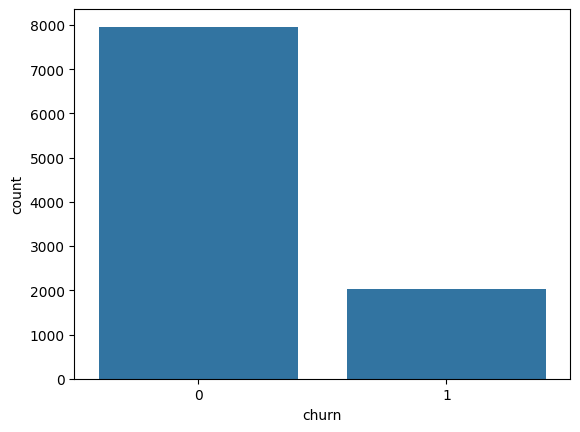

In [25]:
sns.countplot(x='churn', data=churn_df)
plt.show()

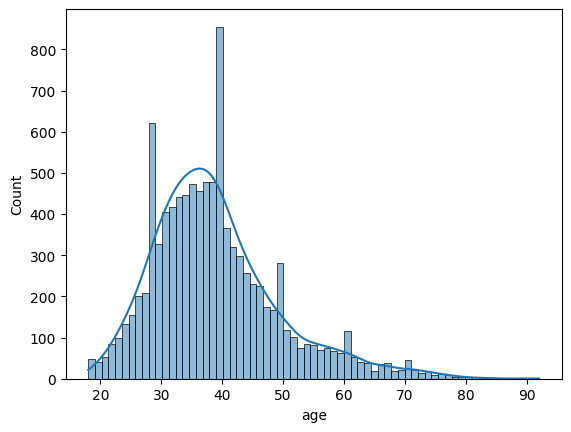

In [26]:
sns.histplot(churn_df['age'], kde=True)
plt.show()

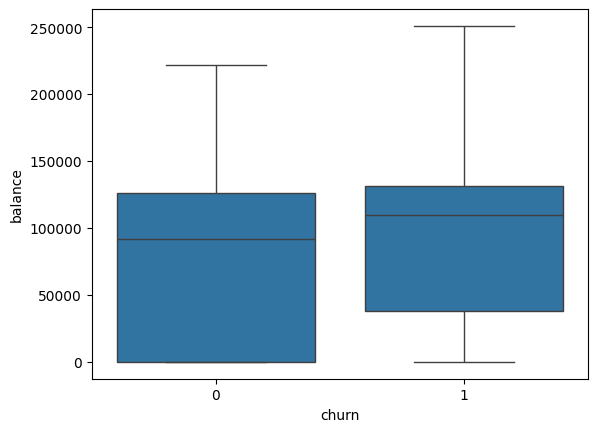

In [27]:
sns.boxplot(x='churn', y='balance', data=churn_df)
plt.show()

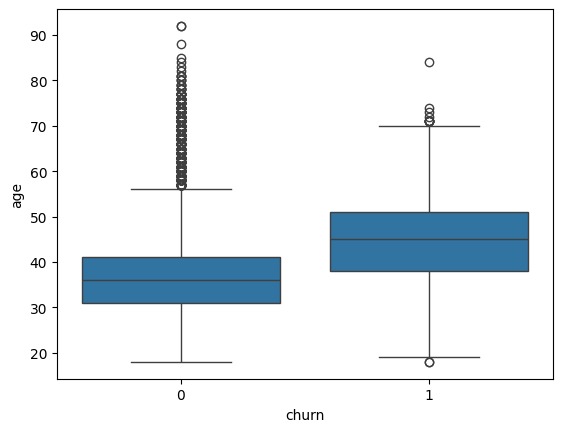

In [28]:
sns.boxplot(x='churn', y='age', data=churn_df)
plt.show()



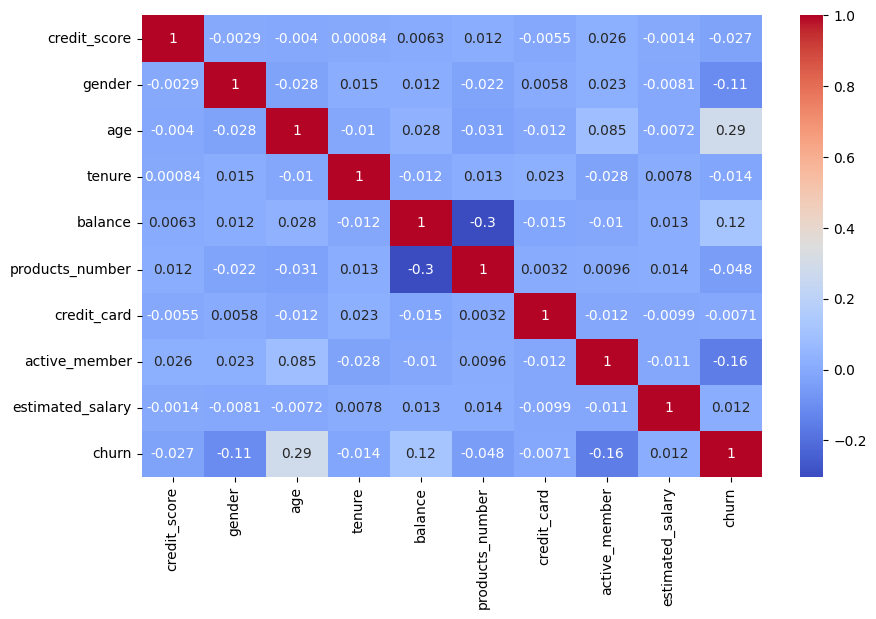

In [29]:
plt.figure(figsize=(10, 6))
sns.heatmap(churn_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [30]:
seg_features = churn_df[['credit_score', 'age', 'balance', 'estimated_salary']]
scaler_seg = StandardScaler()
seg_scaled = scaler_seg.fit_transform(seg_features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
churn_df['CustomerSegment'] = kmeans.fit_predict(seg_scaled)

churn_df[['credit_score', 'age', 'balance', 'estimated_salary', 'CustomerSegment']].head()

,credit_score,age,balance,estimated_salary,CustomerSegment
0,619,42,0.00,101348.88,1
1,608,41,83807.86,112542.58,2
2,502,42,159660.80,113931.57,2
3,699,39,0.00,93826.63,1
4,850,43,125510.82,79084.10,2


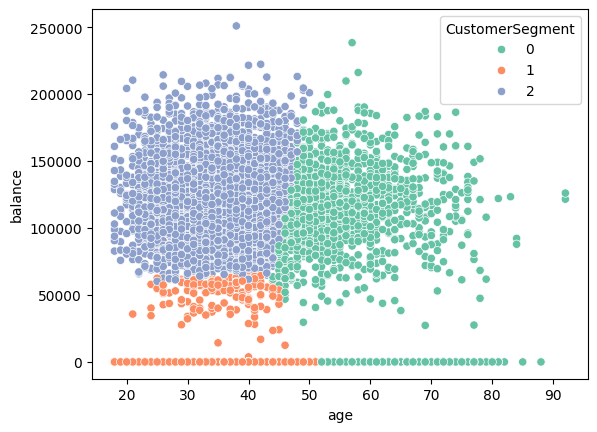

In [31]:
sns.scatterplot(x=churn_df['age'], y=churn_df['balance'], hue=churn_df['CustomerSegment'], palette='Set2')
plt.show()

In [32]:
X_churn = churn_df.drop('churn', axis=1)
y_churn = churn_df['churn']

In [33]:
scaler_churn = StandardScaler()
X_churn_scaled = scaler_churn.fit_transform(X_churn)

In [34]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_churn_scaled, y_churn, test_size=0.2, random_state=42, stratify=y_churn)

In [35]:
churn_model = LogisticRegression(C=0.5, penalty='l2', solver='liblinear', max_iter=1000, class_weight='balanced', random_state=42)
churn_model.fit(Xc_train, yc_train)

LogisticRegression(C=0.5, class_weight='balanced', max_iter=1000,
                   random_state=42, solver='liblinear')

In [36]:
yc_pred = churn_model.predict(Xc_test)
yc_prob = churn_model.predict_proba(Xc_test)[:, 1]

In [37]:
print("Accuracy:", accuracy_score(yc_test, yc_pred))
print("ROC-AUC:", roc_auc_score(yc_test, yc_prob))
print(confusion_matrix(yc_test, yc_pred))
print(classification_report(yc_test, yc_pred))

Accuracy: 0.717
ROC-AUC: 0.7745819779718084
[[1143  450]
 [ 116  291]]
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1593
           1       0.39      0.71      0.51       407

    accuracy                           0.72      2000
   macro avg       0.65      0.72      0.65      2000
weighted avg       0.80      0.72      0.74      2000



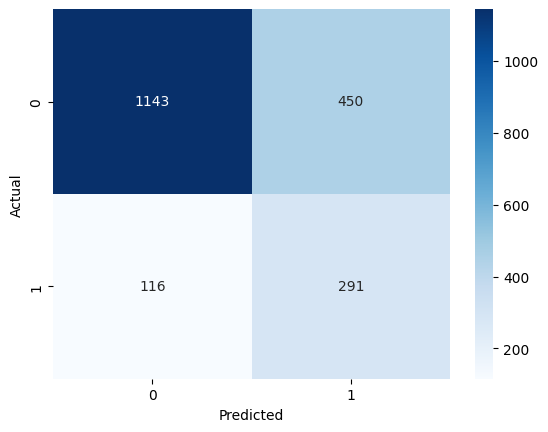

In [38]:
cm = confusion_matrix(yc_test, yc_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

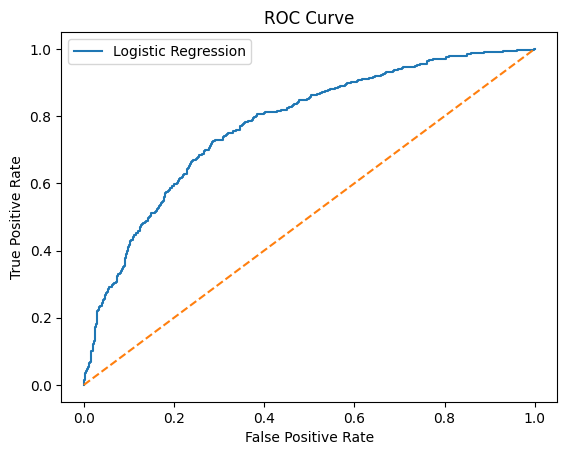

In [39]:
fpr, tpr, thresholds = roc_curve(yc_test, yc_prob)
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [40]:
churn_importance = pd.DataFrame({
    'Feature': X_churn.columns,
    'Coefficient': churn_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

churn_importance


,Feature,Coefficient
2,age,0.666868
4,balance,0.407825
8,estimated_salary,0.051449
3,tenure,-0.017076
6,credit_card,-0.024859
5,products_number,-0.036219
0,credit_score,-0.077610
9,CustomerSegment,-0.181711
1,gender,-0.274407
7,active_member,-0.440938


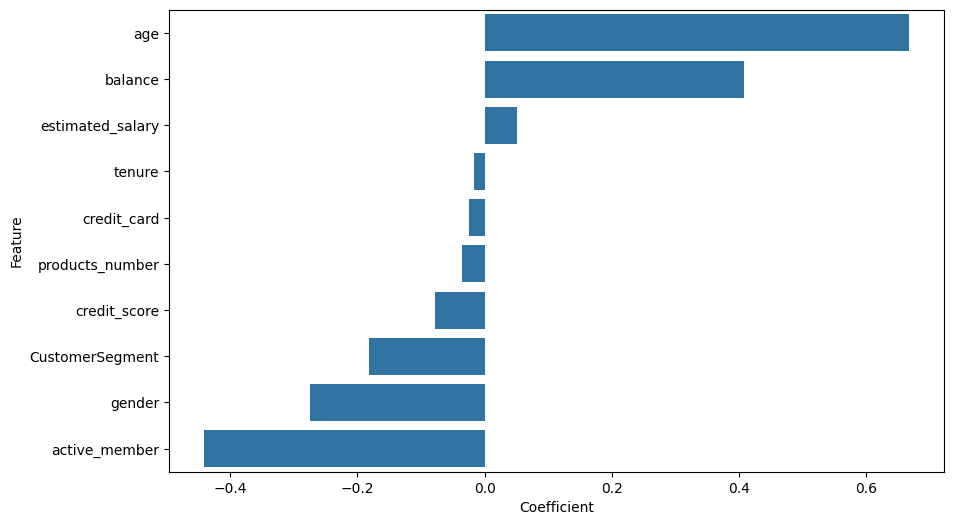

In [41]:
plt.figure(figsize=(10, 6))
sns.barplot(data=churn_importance, x='Coefficient', y='Feature')
plt.show()

In [43]:
segment_churn = churn_df.groupby('CustomerSegment')['churn'].mean().reset_index()
segment_churn

,CustomerSegment,churn
0,0,0.466826
1,1,0.119069
2,2,0.172679


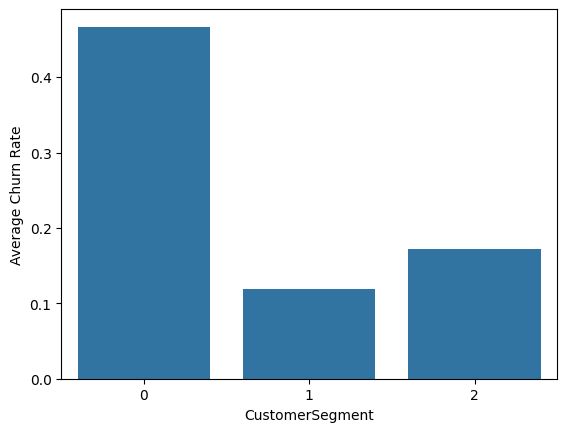

In [44]:
sns.barplot(data=segment_churn, x='CustomerSegment', y='churn')
plt.ylabel('Average Churn Rate')
plt.show()

In [45]:
high_churn_customers = churn_df[churn_df['churn'] == 1]
high_churn_customers[['age', 'balance', 'credit_score', 'estimated_salary', 'CustomerSegment']].describe()

,age,balance,credit_score,estimated_salary,CustomerSegment
count,2037.000000,2037.000000,2037.000000,2037.000000,2037.000000
mean,44.837997,91108.539337,645.351497,101465.677531,1.034855
std,9.761562,58360.794816,100.321503,57912.418071,0.894901
min,18.000000,0.000000,350.000000,11.580000,0.000000
25%,38.000000,38340.020000,578.000000,51907.720000,0.000000
50%,45.000000,109349.290000,646.000000,102460.840000,1.000000
75%,51.000000,131433.330000,716.000000,152422.910000,2.000000
max,84.000000,250898.090000,850.000000,199808.100000,2.000000


In [47]:
avg_age_churn = churn_df[churn_df['churn'] == 1]['age'].mean()
avg_balance_churn = churn_df[churn_df['churn'] == 1]['balance'].mean()

print("Average age of churned customers:", avg_age_churn)
print("Average balance of churned customers:", avg_balance_churn)

if avg_age_churn > 40:
    print("Recommendation: Focus retention campaigns on older customer groups.")
else:
    print("Recommendation: Focus retention campaigns on younger customer groups.")

if avg_balance_churn > 50000:
    print("Recommendation: Premium retention strategy may be required for high-balance customers.")
else:
    print("Recommendation: Low-cost digital engagement strategies may help reduce churn.")

Average age of churned customers: 44.8379970544919
Average balance of churned customers: 91108.53933726068
Recommendation: Focus retention campaigns on older customer groups.
Recommendation: Premium retention strategy may be required for high-balance customers.
